In [1]:
import numpy as np
import re
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
preflop_path = Path.cwd().parent / 'data' / "runs" / "run_001" / "preflop"
rng_seed = 42

def fmt_iters(n: int) -> str:
    if n % 1_000_000_000 == 0 and n >= 1_000_000_000:
        return f"{n // 1_000_000_000}B"
    if n % 1_000_000 == 0 and n >= 1_000_000:
        return f"{n // 1_000_000}M"
    if n % 1_000 == 0 and n >= 1_000:
        return f"{n // 1_000}k"
    return str(n)

def get_preflop_path(iter):
    return preflop_path / ("iter_" + fmt_iters(iter) + ".csv")


In [4]:
#This is all chatbotted! User beware
RANKS = "AKQJT98765432"
BASE_COLORS = {"fold": "#7ea3c4", "check": "#8bbf8b", "call": "#8bbf8b"}
RAISE_COLORS = ["#f0b49a", "#e07b6a", "#c4503c", "#8f2f22"]  # small -> large


def hand_name(i: int, j: int) -> str:
    hi, lo = RANKS[min(i, j)], RANKS[max(i, j)]
    return hi + hi if i == j else hi + lo + ("s" if i < j else "o")


def n_combos(i: int, j: int) -> int:
    return 6 if i == j else (4 if i < j else 12)


def action_colors(cols):
    """Map column names -> colors; raises shaded by size order."""
    def amt(c):
        m = re.search(r"(\d+)", c)
        return int(m.group(1)) if m else 0

    raises = sorted((c for c in cols if c.startswith("raise")), key=amt)
    out = {}
    for c in cols:
        if c in BASE_COLORS:
            out[c] = BASE_COLORS[c]
        else:
            k = raises.index(c)
            out[c] = RAISE_COLORS[min(k, len(RAISE_COLORS) - 1)]
    return out


def plot_preflop_actions(df, title=None,  ax=None, colors=None):
    """13x13 grid, each cell filled left->right by per-action frequency.

    df: one row per hand, 'hand' column plus one column per action.
    """
    strat = df.set_index("hand")
    actions = list(strat.columns)
    colors = colors or action_colors(actions)

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 10))

    weighted = np.zeros(len(actions))
    total = 0.0

    for i in range(13):
        for j in range(13):
            h = hand_name(i, j)
            if h in strat.index:
                p = strat.loc[h, actions].to_numpy(dtype=float)
                p = np.clip(p, 0.0, None)
                s = p.sum()
                if s > 0:
                    p /= s
            else:
                p = np.zeros(len(actions))

            c = n_combos(i, j)
            weighted += p * c
            total += c

            x = j - 0.5
            for w, a in zip(p, actions):
                if w > 0:
                    ax.add_patch(Rectangle((x, i - 0.5), w, 1,
                                           facecolor=colors[a], edgecolor="none"))
                    x += w
            ax.text(j, i, h, ha="center", va="center", fontsize=7.5,
                    color="black", zorder=3)

    ax.set_xlim(-0.5, 12.5)
    ax.set_ylim(12.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(-0.5, 13), minor=True)
    ax.set_yticks(np.arange(-0.5, 13), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(range(13), RANKS)
    ax.set_yticks(range(13), RANKS)
    ax.set_title(title or "Preflop strategy", fontsize=12, pad=10)

    handles = [Rectangle((0, 0), 1, 1, facecolor=colors[a]) for a in actions]
    texts = [f"{a}  {w / total:.1%}  ({w:.1f} combos)"
             for a, w in zip(actions, weighted)]
    ax.legend(handles, texts, loc="upper center", bbox_to_anchor=(0.5, -0.04),
              ncol=min(len(actions), 4), frameon=False, fontsize=10)
    return ax

 

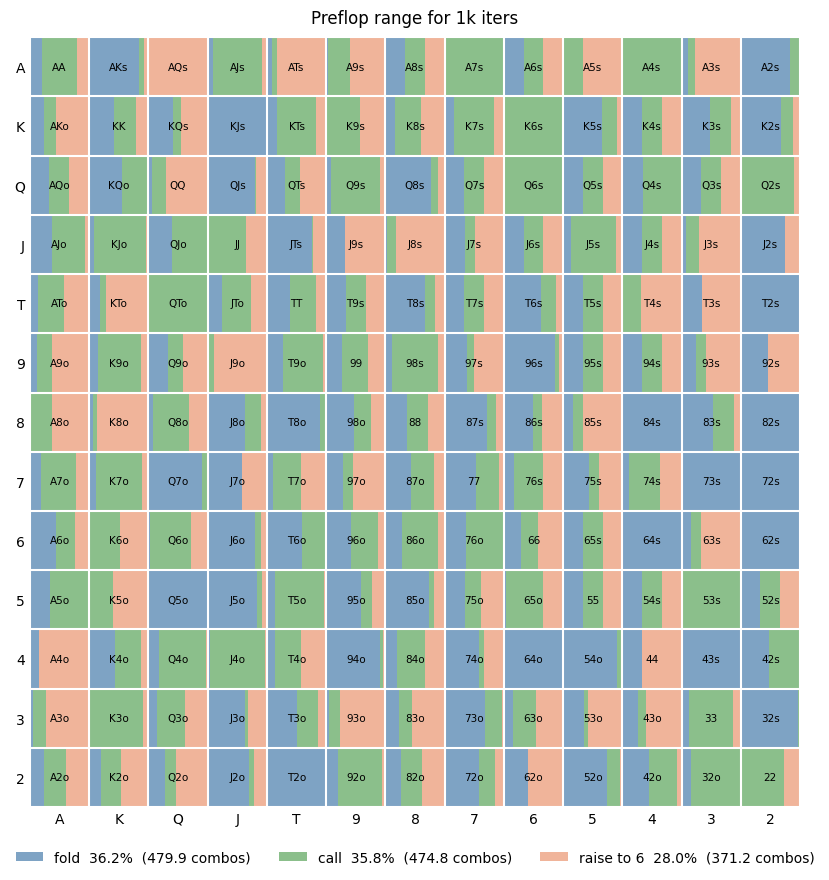

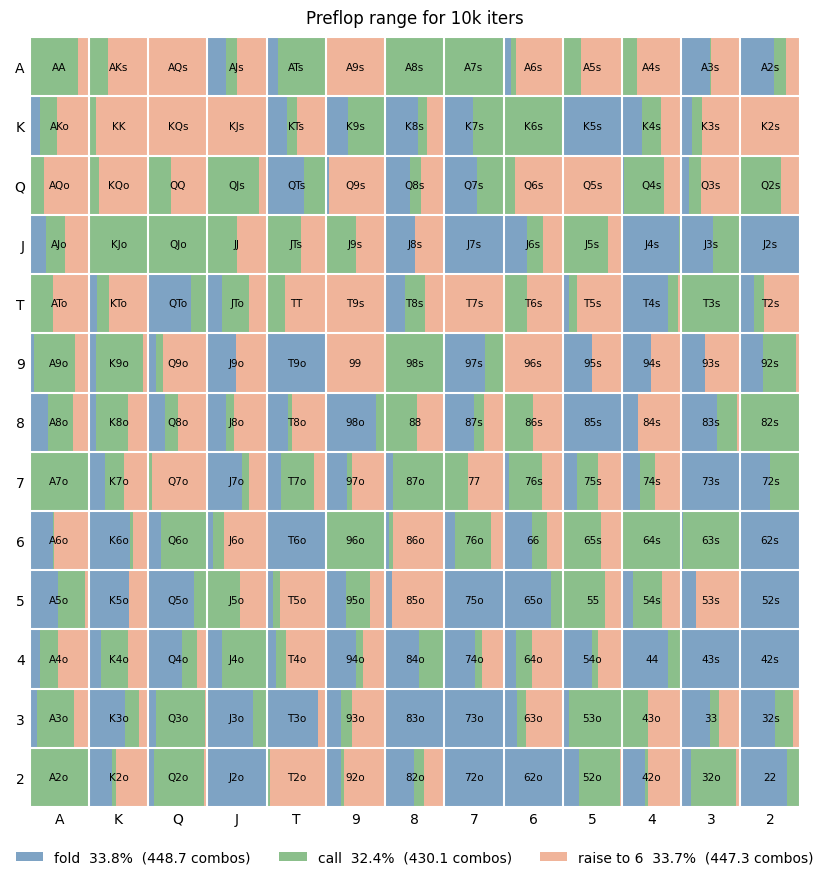

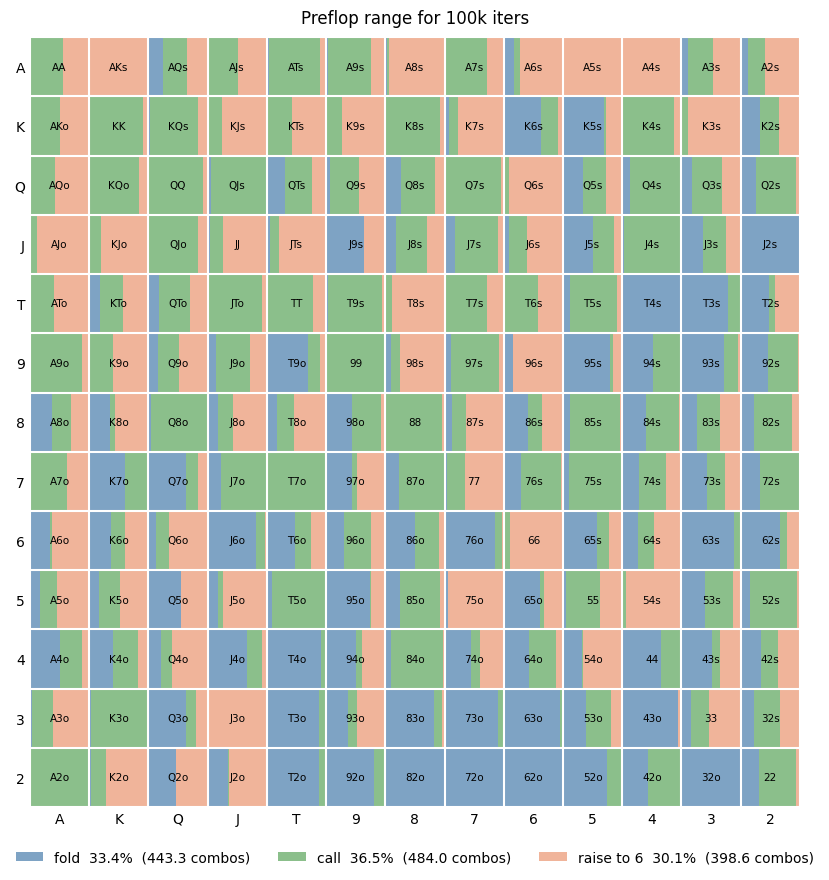

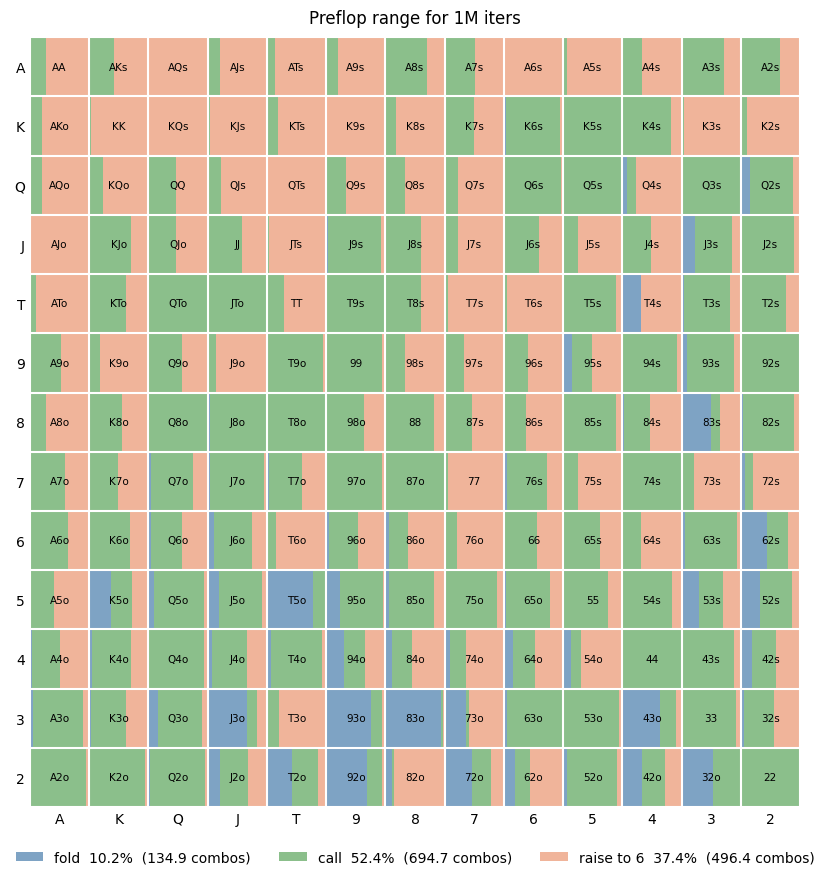

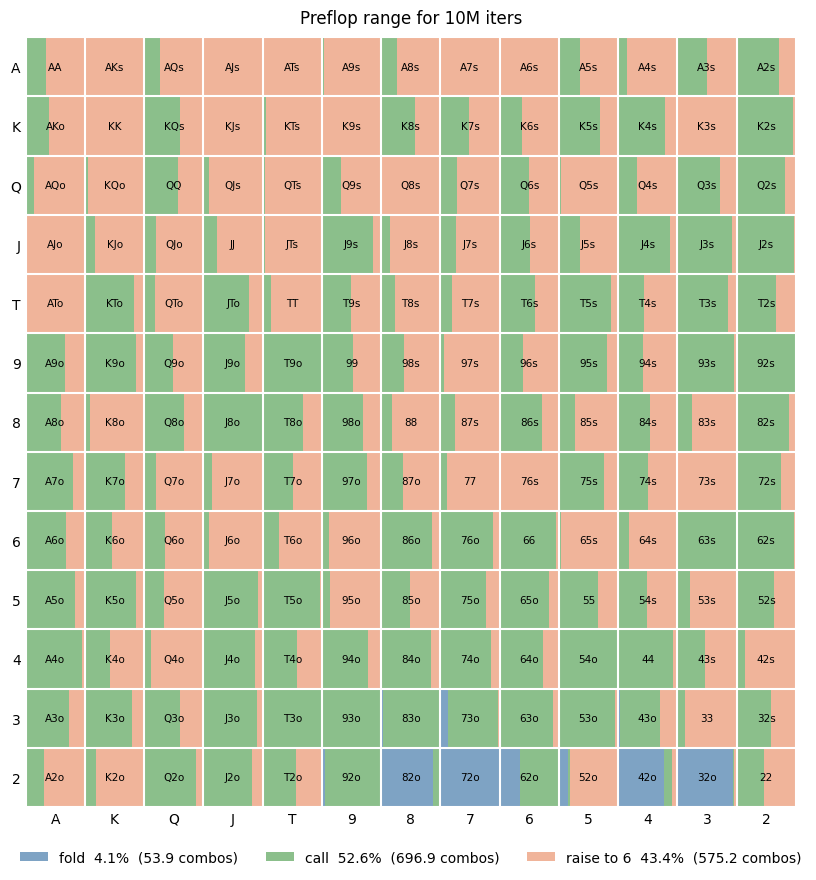

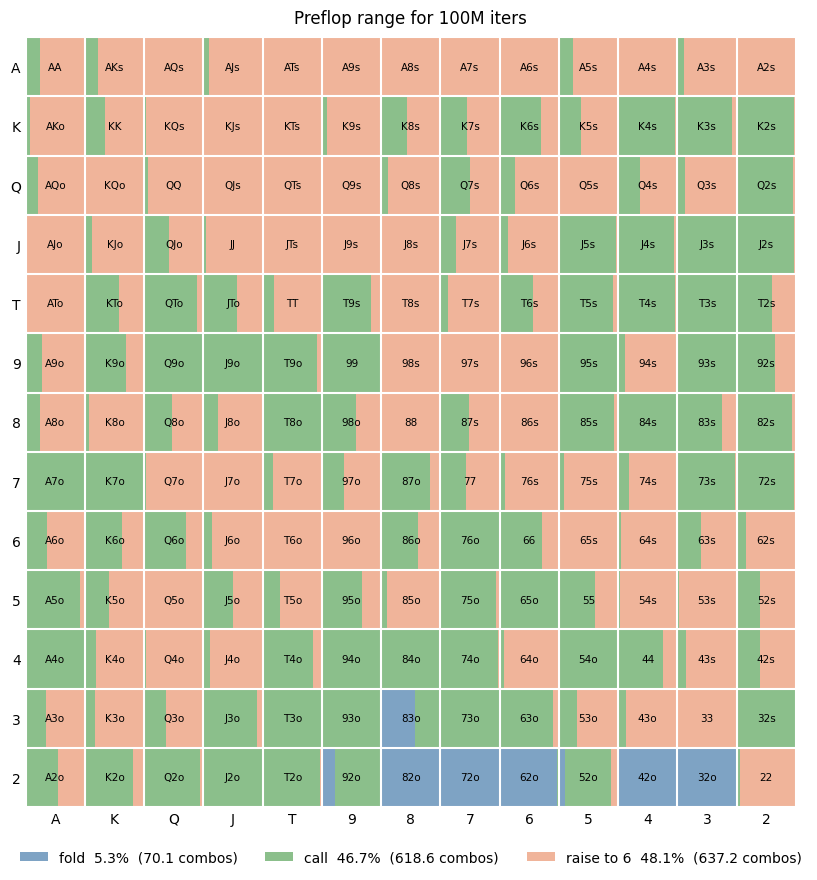

In [9]:
k = 1_000
m = 1_000_000
ckpt_iters = [1*k, 10*k, 100*k, 1*m, 10*m, 100*m] 

for val in ckpt_iters:

    preflop_df = pd.read_csv(get_preflop_path(val))
    title = "Preflop range for " + fmt_iters(val) + " iters"
    plot_preflop_actions(preflop_df, title)
   
